Housing Price Data Visualization In-Class Exercise
------

In this review notebook, we will review the basics of data visualization and the importance of this for being able to build performant ML models. It is also a good starting point for people to get used to Python and the use of Jupyter Notebooks. It is designed as an in-class (or on your own) exercise to get your feet wet in working with data. Specifically, in this notebook we will:

1. Load the California Housing dataset
2. Build some basic visualizations of the dataset
3. Interpret the visualizations and discuss what they mean for building ML models

The below code is a useful starting point that should get you started with exploring the California Housing data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
cal_housing = fetch_california_housing(data_home='.')

In [2]:
print(cal_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
cal_housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [4]:
X = cal_housing.data
avg_price = cal_housing.target
feature_names = cal_housing.feature_names
feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
X[:,0]

array([8.3252, 8.3014, 7.2574, ..., 1.7   , 1.8672, 2.3886])

Text(0, 0.5, 'House Price')

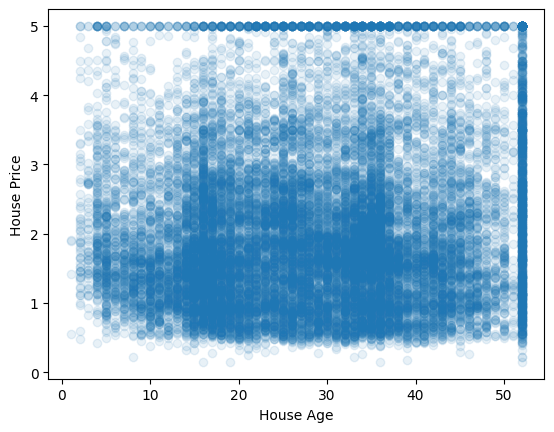

In [6]:
plt.scatter(X[:,1], cal_housing.target, alpha=0.1)
plt.xlabel("House Age")
plt.ylabel("House Price")

Some people might find it useful to use a [Pandas](http://synesthesiam.com/posts/an-introduction-to-pandas.html) [dataframe](http://www.gregreda.com/2013/10/26/intro-to-pandas-data-structures/) to [manipulate the data](http://www.gregreda.com/2013/10/26/working-with-pandas-dataframes/), but that is not really required for basic plotting and visualization: 

In [7]:
import pandas as pd
df=pd.DataFrame(np.hstack([X,avg_price[:,np.newaxis]]),columns=np.hstack([feature_names,'price']))
#Example of the first few rows of data (using the "head" command)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
# Below is how you might select only some columns from a dataframe.
# This is just an illustrative example; you could select other columns
subdf = df[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','price']]
subdf.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,3.422


In [9]:
# Summary statistics (count, mean, min, max, ...) for every column at once
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
# Looping over the columns of a dataframe.
# Useful when you want to repeat the same thing (e.g., a plot) for every feature.
for column in df.columns:
    print(column, df[column].mean())

MedInc 3.8706710029069766
HouseAge 28.639486434108527
AveRooms 5.428999742190376
AveBedrms 1.096675149606208
Population 1425.4767441860465
AveOccup 3.0706551594363742
Latitude 35.63186143410853
Longitude -119.56970445736432
price 2.068558169089147


For the below tasks, you might want to try out some basic Python plotting libraries. I recommend:

* [Matplotlib](http://matplotlib.org/): Fairly basic building block, but gets the job done, and widely used. This is the most complicated option, but gives you the most control.
* [Bokeh](http://bokeh.pydata.org/en/latest/): Fancier interactive graphs with scrolling. Fairly easy to use.
* [Seaborn](https://stanford.edu/~mwaskom/software/seaborn/): Probably the easiest to use to produce basic, common graphs and statistics.

If you aren't familiar with any of the above libraries, I would suggest starting with Seaborn, since it hides many of the complex features you might not need right away (check out their [tutorial](https://stanford.edu/~mwaskom/software/seaborn/tutorial/distributions.html)). Bokeh also has a nice [Quick Start guide](http://bokeh.pydata.org/en/latest/docs/user_guide/quickstart.html#userguide-quickstart) if you like having the ability to pan/zoom the data.

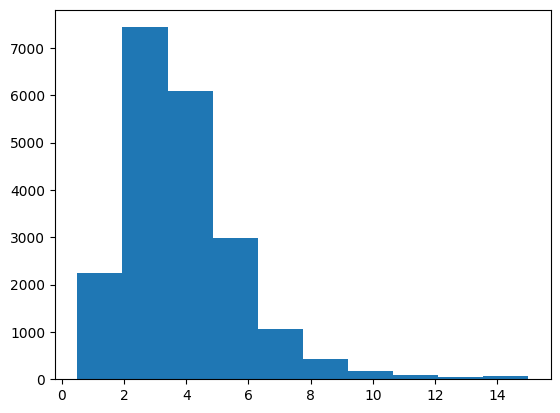

In [11]:
# Matplotlib plotting example
# Below line tells the notebook to plots the images here
# in the notebook, rather than separately as image files.
%matplotlib inline 
import matplotlib.pyplot as plt
plt.hist(df['MedInc'])
plt.show()

In [12]:
# Pandas Example- Uncomment below and run if you want
# Note, this is essentially just a shortcut to matplotlib
#df['MedInc'].hist()
# or
#df.plot(kind='scatter', x='MedInc', y='price')

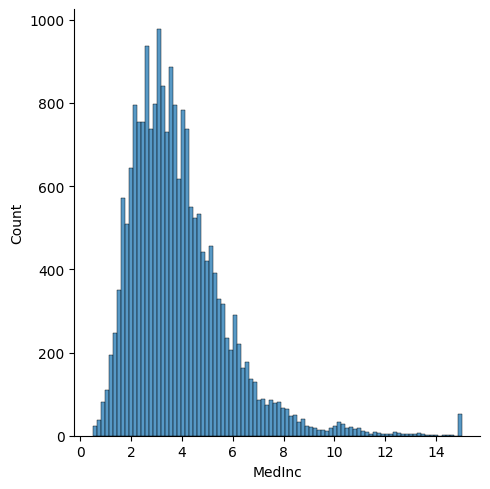

In [13]:
# Seaborn Example - Uncomment below and run if you want
import seaborn as sns  
# Note, just importing seaborn changes the matplotlib default behavior
sns.displot(df['MedInc'])
plt.show()

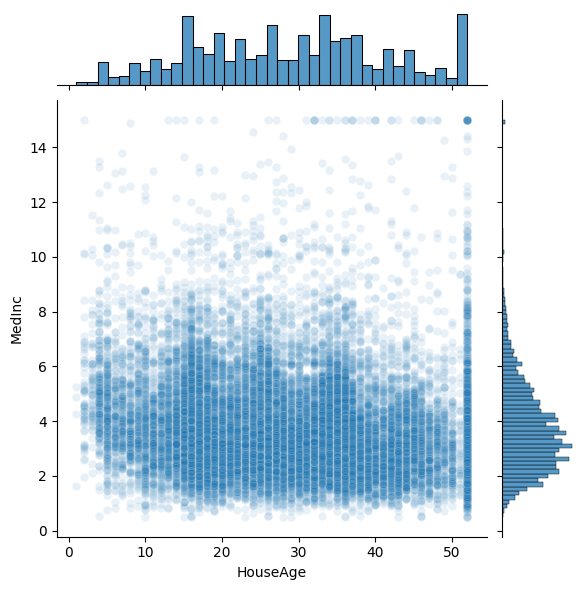

In [14]:
# Seaborn 2D example: a scatter plot of two columns, with each column's 1D distribution along the sides
sns.jointplot(x=df['HouseAge'], y=df['MedInc'], alpha=0.1)
plt.show()

## Exercise 1: Visualize the relationship between features and price
Visualize the 2D relationship between housing prices and the provided features of the data. You can choose how you want to do this. 

[Enter your code into the empty cell below to create the necessary visualizations. You can create multiple cells for code or Markdown code if that helps you.]


In [15]:
# Your code for Exercise 1 goes here


**Question**: Do any of the features appear linearly correlated with price?

## Exercise 2: Visualize the relationships between features
Visualize the 1D and 2D relationships between the features in the dataset. For example, how are house ages distributed? What is the relationship between house age and the number of bedrooms? Feel free to explore different 1D and 2D options.

In [16]:
# Your code for Exercise 2 goes here


**Question**: Are there any anomalies that look strange in the data, and which visualization helped you identify them (hint: there should be several)?

## Exercise 3: Visualize relationships with the Anomalies Removed
Using your knowledge of the anomalies you found above, remove those anomalies using appropriate code below (either by removing the entire data record, or just the specific values that were anomalous, if you prefer to be more surgical) and replot the Task 1 and Task 2 plots you produced above.

In [17]:
# Selecting only the rows of a dataframe that satisfy a condition (a "boolean mask")
old_houses = df[df['HouseAge'] > 40]
print(len(df), len(old_houses))

# Combining conditions: & means "and", | means "or"
old_and_expensive = df[(df['HouseAge'] > 40) & (df['price'] > 3)]
print(len(old_and_expensive))
old_and_expensive.head()

20640 3878
1030


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.52100
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.41300
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.42200
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001


In [18]:
# Code goes here for dealing with outliers
# You can copy/paste some of your plotting code from above, if that is helpful.

**Question**: Does this change your answer to the original Task 1 or Task 2 questions?

## Solutions

<details>
<summary><b>Solution: Exercise 1</b> (click to expand)</summary>

```python
features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']
for feature in features:
    sns.jointplot(x=df[feature], y=df['price'], alpha=0.1)
    plt.show()
```

</details>

<details>
<summary><b>Solution: Exercise 2</b> (click to expand)</summary>

```python
# 1D distribution of each feature
for feature in features:
    sns.displot(df[feature])
    plt.show()

# 2D relationship between each pair of features
for i, feature in enumerate(features):
    for j, feature2 in enumerate(features):
        if j > i:
            sns.jointplot(x=df[feature], y=df[feature2], alpha=1.0)
            plt.show()
```

</details>

<details>
<summary><b>Solution: Exercise 3</b> (click to expand)</summary>

```python
# Anomalies found above: price is capped at 5 (i.e. $500k), HouseAge is capped at 52,
# and a handful of records have extreme values of AveRooms, AveBedrms, Population and AveOccup.
clean_df = df[(df['price'] < 5) &
              (df['HouseAge'] < 52) &
              (df['AveRooms'] < 20) &
              (df['AveBedrms'] < 5) &
              (df['Population'] < 10000) &
              (df['AveOccup'] < 20)]
print(len(df), len(clean_df))

# Exercise 1 plots, repeated on the cleaned data
for feature in features:
    sns.jointplot(x=clean_df[feature], y=clean_df['price'], alpha=0.1)
    plt.show()

# Exercise 2 plots, repeated on the cleaned data
for feature in features:
    sns.displot(clean_df[feature])
    plt.show()

for i, feature in enumerate(features):
    for j, feature2 in enumerate(features):
        if j > i:
            sns.jointplot(x=clean_df[feature], y=clean_df[feature2], alpha=1.0)
            plt.show()
```

</details>